In [1]:
library(Seurat)
library(CellChat)
library(tidyverse)
library(readxl)
library(patchwork)

The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject

Loading required package: dplyr


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: ‘igraph’


The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union


The following objects are masked from ‘package:stats’:

    decompose, spectrum


The following object is masked from ‘package:base’:

    union


Loading required package: ggplot2

Warning message:
“package ‘tibble’ was built under R version 4.2.3”
Warning message in system("timedatectl", intern = TRUE):
“running command '

In [ ]:
# data.dir <- './comparison'
# dir.create(data.dir)
# setwd(data.dir)

## （1） merge data

In [2]:
cellchat.normal <- readRDS('/data/work/02.result/others/Chen/macrophage/All_cell/cellchat/normal/cellchat.rds')
cellchat.early <- readRDS('/data/work/02.result/others/Chen/macrophage/All_cell/cellchat/early/cellchat.rds')
cellchat.middle <- readRDS('/data/work/02.result/others/Chen/macrophage/All_cell/cellchat/middle/cellchat.rds')

object.list <- list(normal = cellchat.normal, early = cellchat.early, middle = cellchat.middle)
cellchat <- mergeCellChat(object.list, add.names = names(object.list))
#> Merge the following slots: 'data.signaling','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.
cellchat


Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



An object of class CellChat created from a merged object with multiple datasets 
 952 signaling genes.
 80480 cells. 
CellChat analysis of single cell RNA-seq data! 

In [ ]:
# 在 CellChat 的多数据集分析中，你的理解大部分是正确的，但在不同函数下，比较的数量限制略有不同。

# 1. object.list 可以传入 3 个对象吗？
#     可以。 CellChat 的 mergeCellChat 函数支持传入任意数量的对象（2个、3个甚至更多）


# 2. compareInteractions 中 group = c(1, 2) 的限制

#     参数含义：group = c(1, 2) 告诉 R 提取 object.list 中的第 1 个和第 2 个数据集进行对比。
#     如果你有 3 个组：group = c(1,2,3)。
#     解决方案：如果你想看三个组的整体趋势，建议使用 rankNet 函数，它可以同时展示任意数量数据集的信号通路强度对比。
#     # 同时展示 Normal, Early, Middle 的通路强度排名对比
#     rankNet(cellchat, mode = "comparison", stacked = T, do.stat = TRUE)

#     分析函数	是否支持 3 个或更多对象？	说明
#     netVisual_diffInteraction	不支持	这种“红色/蓝色”圆圈图（Differential network）只能展示两组相减的结果（如 LS - NL）。
#     netVisual_heatmap	不支持	差异热图同样只能计算两个矩阵的差值。
#     rankNet	支持	可以并排或堆叠显示 3 个组中各个通路的相对强度。
#     netAnalysis_signalingRole_scatter	支持	会为每个组生成一个散点图，方便横向观察角色转变。


# 3. 针对 3 个组的操作建议

#     如果你想分析 Normal -> Early -> Middle 的演变，建议采取以下策略：
#     全局对比：使用 rankNet 同时放入三个组，查看哪些通路随疾病进展持续增强。

#     两两差异：
#     比较 Early vs Normal（看起病诱因）。
#     比较 Middle vs Early（看进展机制）。

#     # 对比 Early(2) 和 Normal(1)
#     netVisual_diffInteraction(cellchat, weight.scale = T, group = c(1, 2))
#     # 对比 Middle(3) 和 Early(2)
#     netVisual_diffInteraction(cellchat, weight.scale = T, group = c(2, 3))

## （2）plot

In [4]:
cellchat

An object of class CellChat created from a merged object with multiple datasets 
 952 signaling genes.
 80480 cells. 
CellChat analysis of single cell RNA-seq data! 

In [5]:
str(cellchat)

Formal class 'CellChat' [package "CellChat"] with 15 slots
  ..@ data.raw      : num[0 , 0 ] 
  ..@ data          : num[0 , 0 ] 
  ..@ data.signaling:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. ..@ i       : int [1:5745962] 68 69 93 94 97 107 110 119 120 126 ...
  .. .. ..@ p       : int [1:80481] 0 48 106 152 209 253 300 375 458 526 ...
  .. .. ..@ Dim     : int [1:2] 952 80480
  .. .. ..@ Dimnames:List of 2
  .. .. .. ..$ : chr [1:952] "AGRN" "TNFRSF18" "TNFRSF4" "TNFRSF14" ...
  .. .. .. ..$ : chr [1:80480] "p018_AAACCCACAACTTGGT-1" "p018_AAACCCACAAGAATAC-1" "p018_AAACCCACATCCGGCA-1" "p018_AAACCCACATGATCTG-1" ...
  .. .. ..@ x       : num [1:5745962] 1.8 1.8 1.8 3.27 3.27 ...
  .. .. ..@ factors : list()
  ..@ data.scale    : num[0 , 0 ] 
  ..@ data.project  : num[0 , 0 ] 
  ..@ images        :List of 3
  .. ..$ normal: list()
  .. ..$ early : list()
  .. ..$ middle: list()
  ..@ net           :List of 3
  .. ..$ normal:List of 4
  .. .. ..$ prob  : num [1:10, 1

#### (1) 比较交互总数和交互强度

In [16]:
pdf("1._CellChat_network_Number&strength.pdf", width = 5, height = 5)

gg1 <- compareInteractions(cellchat, show.legend = F, group = c(1,2,3))
print(gg1)   # 第 1 页

gg2 <- compareInteractions(cellchat, show.legend = F, group = c(1,2,3), measure = "weight")
print(gg2)   # 第 2 页

dev.off()

png 
  2

In [8]:
pdf("1.1_CellChat_circle_network_Number.pdf", width = 18, height = 6)

weight.max <- getMaxWeight(object.list, attribute = c("idents","count"))
par(mfrow = c(1,3), xpd=TRUE)
for (i in 1:length(object.list)) {
  netVisual_circle(object.list[[i]]@net$count, weight.scale = T, label.edge= F, edge.weight.max = weight.max[2], edge.width.max = 12, title.name = paste0("Number of interactions - ", names(object.list)[i]))
}


dev.off()

png 
  2

In [51]:
pdf("1.2_CellChat_circle_network_weights.pdf", width = 18, height = 6)

weight.max <- getMaxWeight(object.list, attribute = c("idents","count"))
par(mfrow = c(1,3), xpd=TRUE)
for (i in 1:length(object.list)) {
  netVisual_circle(object.list[[i]]@net$weight, weight.scale = T, label.edge= F,  title.name = paste0("Interaction weights/strength - ", names(object.list)[i]))
}
# edge.weight.max = weight.max[2], edge.width.max = 50,

dev.off()

png 
  2

In [ ]:
gg1 <- netVisual_heatmap(cellchat, comparison = c(1,2,3), measure = "count")
print(gg1)
# gg2 <- netVisual_heatmap(cellchat, comparison = c(1,2,3), measure = "weight")

# gg1 + gg2

In [63]:
library(grid)

pdf("1.6_CellChat_heatmap_pairwise_count.pdf", width = 6, height = 6)

# =========================
# 第 1 页：Early vs Normal
# =========================
grid.newpage()
p1 <- netVisual_heatmap(
  cellchat,
  comparison = c(1, 2),
  measure = "count",
  title.name = "Count: Early vs Normal"
)
print(p1)

# =========================
# 第 2 页：Middle vs Normal
# =========================
grid.newpage()
p2 <- netVisual_heatmap(
  cellchat,
  comparison = c(1, 3),
  measure = "count",
  title.name = "Count: Middle vs Normal"
)
print(p2)

# =========================
# 第 3 页：Middle vs Early
# =========================
grid.newpage()
p3 <- netVisual_heatmap(
  cellchat,
  comparison = c(2, 3),
  measure = "count",
  title.name = "Count: Middle vs Early"
)
print(p3)

dev.off()


Do heatmap based on a merged object 


Do heatmap based on a merged object 


Do heatmap based on a merged object 




png 
  2

In [67]:
library(grid)

pdf("1.6_CellChat_heatmap_pairwise_weight.pdf", width = 6, height = 6)

# =========================
# 第 1 页：Early vs Normal
# =========================
grid.newpage()
p1 <- netVisual_heatmap(
  cellchat,
  comparison = c(1, 2),
  measure = "weight",
  title.name = "weight: Early vs Normal"
)
print(p1)

# =========================
# 第 2 页：Middle vs Normal
# =========================
grid.newpage()
p2 <- netVisual_heatmap(
  cellchat,
  comparison = c(1, 3),
  measure = "weight",
  title.name = "weight: Middle vs Normal"
)
print(p2)

# =========================
# 第 3 页：Middle vs Early
# =========================
grid.newpage()
p3 <- netVisual_heatmap(
  cellchat,
  comparison = c(2, 3),
  measure = "weight",
  title.name = "weight: Middle vs Early"
)
print(p3)

dev.off()


Do heatmap based on a merged object 


Do heatmap based on a merged object 


Do heatmap based on a merged object 




png 
  2

In [59]:
# 只建议 Supplementary，Heatmap showing differential interaction counts in early- and middle-stage samples relative to the normal reference.
# 把 dataset 2 vs 1、dataset 3 vs 1 的差异“合并/叠加”成一个 heatmap

p_all <- netVisual_heatmap(
  cellchat,
  comparison = c(1, 2, 3),
  measure = "count"
)

pdf("1.5_CellChat_heatmap_combined_vs_normal_count.pdf", width = 6, height = 6)
print(p_all)
dev.off()


Do heatmap based on a merged object 




png 
  2

In [20]:
pdf("1.3_CellChat_rankNet_comparison.pdf", width = 12, height = 12)

## ---------- weight ----------
gg1 <- rankNet(cellchat, mode = "comparison", comparison = c(1,2,3), measure = 'weight', stacked = T, do.stat = TRUE)
gg2 <- rankNet(cellchat, mode = "comparison", comparison = c(1,2,3), measure = 'weight',stacked = F, do.stat = TRUE)
gg1 + gg2

## ---------- count ----------
gg1 <- rankNet(cellchat, mode = "comparison", comparison = c(1,2,3), measure = 'count', stacked = T, do.stat = TRUE)
gg2 <- rankNet(cellchat, mode = "comparison", comparison = c(1,2,3), measure = 'count',stacked = F, do.stat = TRUE)
gg1 + gg2

dev.off()

The text on the y-axis will not be colored for the number of compared datasets larger than 3!

The text on the y-axis will not be colored for the number of compared datasets larger than 3!

The text on the y-axis will not be colored for the number of compared datasets larger than 3!

The text on the y-axis will not be colored for the number of compared datasets larger than 3!



png 
  2

In [23]:
# 对每个对象分别计算 centrality

object.list <- lapply(object.list, function(x) {
  netAnalysis_computeCentrality(x, slot.name = "netP")
})


dir.create("Pathway_Plots", showWarnings = FALSE) # 创建输出目录
all_LR <- list() # 用于收集所有 pathway 的 LR 数据

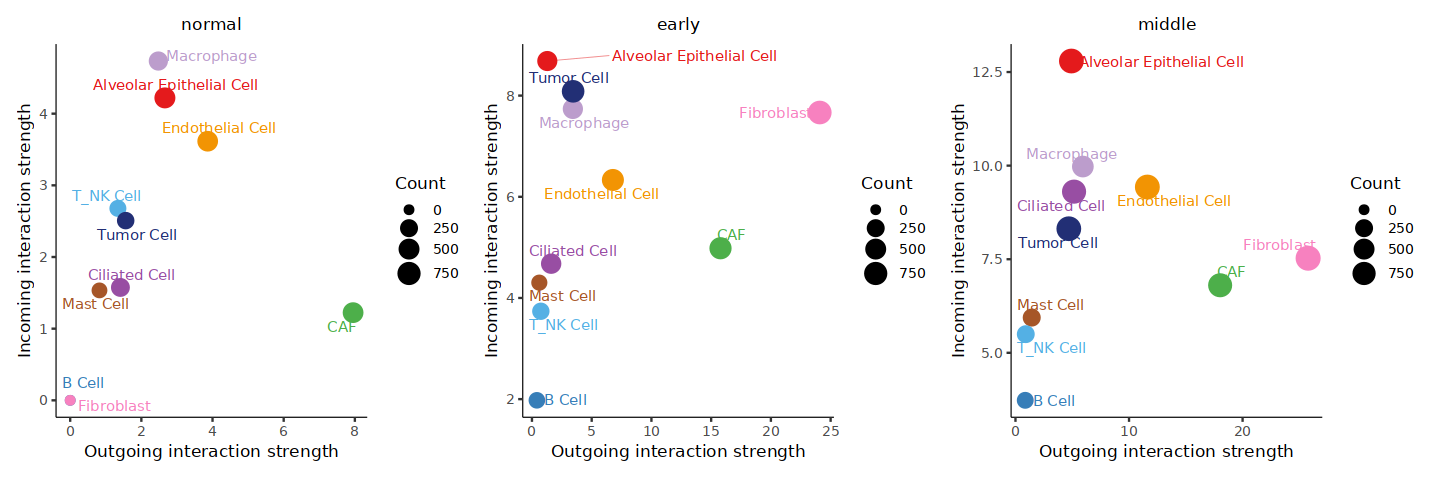

In [26]:
options(repr.plot.width=12,repr.plot.height=4)

# num.link <- sapply(object.list, function(x) {rowSums(x@net$count) + colSums(x@net$count)-diag(x@net$count)})
# weight.MinMax <- c(min(num.link), max(num.link)) # control the dot size in the different datasets
# gg <- list()
# for (i in 1:length(object.list)) {
#   gg[[i]] <- netAnalysis_signalingRole_scatter(object.list[[i]], title = names(object.list)[i], weight.MinMax = weight.MinMax)
# }

patchwork::wrap_plots(plots = gg)

library(patchwork)

pdf("1.4_CellChat_signalingRole_scatter_comparison.pdf", width = 12, height = 4)
wrap_plots(gg, nrow = 1)
dev.off()


In [31]:
object.list

$normal
An object of class CellChat created from a single dataset 
 39434 genes.
 25697 cells. 
CellChat analysis of single cell RNA-seq data! 

$early
An object of class CellChat created from a single dataset 
 39434 genes.
 25215 cells. 
CellChat analysis of single cell RNA-seq data! 

$middle
An object of class CellChat created from a single dataset 
 39434 genes.
 29568 cells. 
CellChat analysis of single cell RNA-seq data! 


In [48]:
# 1. 设置 PDF 输出文件名及尺寸 (宽12英寸, 高18英寸适合 2x3 布局)
pdf("2._CellChat_Differential_Interactions_Stage_Comparison.pdf", width = 10, height = 10)

par(mfrow = c(1, 1), xpd = TRUE, mar = c(1, 1, 3, 1))

# --- 第一行：Normal vs Early ---
# Weight (强度)
p1 <- netVisual_diffInteraction(cellchat, weight.scale = T, measure = "weight", 
                          comparison = c(1, 2), title.name = "Weight: Early vs Normal", arrow.size = 0.5)
print(p1)


# Count (数量)
p2 <- netVisual_diffInteraction(cellchat, weight.scale = T, measure = "count", 
                          comparison = c(1, 2), title.name = "Count: Early vs Normal", arrow.size = 0.5)
print(p2)

# --- 第二行：Normal vs Middle ---
# Weight
p3 <- netVisual_diffInteraction(cellchat, weight.scale = T, measure = "weight", 
                          comparison = c(1, 3), title.name = "Weight: Middle vs Normal", arrow.size = 0.5)
print(p3)

# Count
p4 <- netVisual_diffInteraction(cellchat, weight.scale = T, measure = "count", 
                          comparison = c(1, 3), title.name = "Count: Middle vs Normal", arrow.size = 0.5)
print(p4)

# --- 第三行：Early vs Middle ---
# Weight
p5 <- netVisual_diffInteraction(cellchat, weight.scale = T, measure = "weight", 
                          comparison = c(2, 3), title.name = "Weight: Middle vs Early", arrow.size = 0.5)
print(p5)

# Count
p6 <- netVisual_diffInteraction(cellchat, weight.scale = T, measure = "count", 
                          comparison = c(2, 3), title.name = "Count: Middle vs Early", arrow.size = 0.5)
print(p6)


dev.off()

png 
  2

##### 比较每个细胞群相关的传出（或传入）信号

In [88]:
# (1) 传入传出 all

library(ComplexHeatmap)
library(grid)

# # 确保 centrality 已计算
# object.list <- lapply(object.list, function(x) {
#   netAnalysis_computeCentrality(x, slot.name = "netP")
# })

# union 所有 pathway
pathway.union <- Reduce(
  union,
  lapply(object.list, function(x) x@netP$pathways)
)

pdf("3.1_CellChat_signalingRole_incoming&outgoing_3stages.pdf", width = 6, height = 7)

# ======================
# Normal
# ======================
grid.newpage()
ht1 <- netAnalysis_signalingRole_heatmap(
  object.list[[1]],
  pattern = "all",
  font.size = 2,
  signaling = pathway.union,
    width = 6,
    height = 8,
  title = names(object.list)[1]
)
draw(ht1)

# ======================
# Early
# ======================
grid.newpage()
ht2 <- netAnalysis_signalingRole_heatmap(
  object.list[[2]],
  pattern = "all",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[2]
)
draw(ht2)

# ======================
# Middle
# ======================
grid.newpage()
ht3 <- netAnalysis_signalingRole_heatmap(
  object.list[[3]],
  pattern = "all",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[3]
)
draw(ht3)

dev.off()


png 
  2

In [89]:
# (2) 传出 outgoing

library(ComplexHeatmap)
library(grid)

# # 确保 centrality 已计算
# object.list <- lapply(object.list, function(x) {
#   netAnalysis_computeCentrality(x, slot.name = "netP")
# })

# union 所有 pathway
pathway.union <- Reduce(
  union,
  lapply(object.list, function(x) x@netP$pathways)
)

pdf("3.1_CellChat_signalingRole_outgoing_3stages.pdf", width = 6, height = 7)

# ======================
# Normal
# ======================
grid.newpage()
ht1 <- netAnalysis_signalingRole_heatmap(
  object.list[[1]],
  pattern = "outgoing",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[1]
)
draw(ht1)

# ======================
# Early
# ======================
grid.newpage()
ht2 <- netAnalysis_signalingRole_heatmap(
  object.list[[2]],
  pattern = "outgoing",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[2]
)
draw(ht2)

# ======================
# Middle
# ======================
grid.newpage()
ht3 <- netAnalysis_signalingRole_heatmap(
  object.list[[3]],
  pattern = "outgoing",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[3]
)
draw(ht3)

dev.off()


png 
  2

In [90]:
# (3) 传入 incoming

library(ComplexHeatmap)
library(grid)

# # 确保 centrality 已计算
# object.list <- lapply(object.list, function(x) {
#   netAnalysis_computeCentrality(x, slot.name = "netP")
# })

# union 所有 pathway
pathway.union <- Reduce(
  union,
  lapply(object.list, function(x) x@netP$pathways)
)

pdf("3.1_CellChat_signalingRole_incoming_3stages.pdf", width = 6, height = 7)

# ======================
# Normal
# ======================
grid.newpage()
ht1 <- netAnalysis_signalingRole_heatmap(
  object.list[[1]],
  pattern = "incoming",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[1]
)
draw(ht1)

# ======================
# Early
# ======================
grid.newpage()
ht2 <- netAnalysis_signalingRole_heatmap(
  object.list[[2]],
  pattern = "incoming",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[2]
)
draw(ht2)

# ======================
# Middle
# ======================
grid.newpage()
ht3 <- netAnalysis_signalingRole_heatmap(
  object.list[[3]],
  pattern = "incoming",
    font.size = 2,
    width = 6,
    height = 8,
  signaling = pathway.union,
  title = names(object.list)[3]
)
draw(ht3)

dev.off()


png 
  2

#### (2) 配受体对 LR plots

In [65]:
object.list

$normal
An object of class CellChat created from a single dataset 
 39434 genes.
 25697 cells. 
CellChat analysis of single cell RNA-seq data! 

$early
An object of class CellChat created from a single dataset 
 39434 genes.
 25215 cells. 
CellChat analysis of single cell RNA-seq data! 

$middle
An object of class CellChat created from a single dataset 
 39434 genes.
 29568 cells. 
CellChat analysis of single cell RNA-seq data! 


In [ ]:
# library(CellChat)
# library(future)

# assign(
#   "multiprocess",
#   future::multisession,
#   envir = asNamespace("future")
# )


# # 1. signaling network 相似性
# cellchat <- computeNetSimilarityPairwise(
#   cellchat,
#   type = "functional"
# )

# # 2. 网络嵌入
# cellchat <- netEmbedding(
#   cellchat,
#   type = "functional"
# )


# # 3. 网络聚类（现在一定不会再报 multiprocess）
# cellchat <- netClustering(
#   cellchat,
#   type = "functional"
# )

# # 4. 2D embedding 可视化
# netVisual_embeddingPairwise(
#   cellchat,
#   type = "functional",
#   label.size = 3.5
# )


In [96]:
## 总的 LR bubble

pdf("4.1_CellChat_LR_bubble.pdf", width = 25, height = 18)

netVisual_bubble(cellchat,  comparison = c(1, 2,3), font.size = 2, angle.x = 45) # 
#> Comparing communications on a merged object

dev.off()

Comparing communications on a merged object 




png 
  2

In [106]:
## 总的 LR bubble

pdf("4.2_CellChat_LR_bubble_T-NK.pdf", width = 5, height = 8)

netVisual_bubble(cellchat, 
                 sources.use = c("Macrophage", "T_NK Cell", "B Cell"), 
                 targets.use = c("Tumor Cell"),  comparison = c(1, 2, 3), font.size = 7, angle.x = 45) # sources.use = 4, targets.use = c(5:11), 
#> Comparing communications on a merged object

dev.off()

Comparing communications on a merged object 




png 
  2

In [102]:
unique(cellchat@meta$sub)

levels(cellchat@idents)


[1] "Macrophage"               "Ciliated Cell"           
 [3] "Mast Cell"                "Alveolar Epithelial Cell"
 [5] "Endothelial Cell"         "T_NK Cell"               
 [7] "B Cell"                   "Tumor Cell"              
 [9] "CAF"                      "Fibroblast"

NULL

In [113]:
# 1️⃣ 看 LR 层面是否存在
cellchat@net$prob |> is.null()

# 2️⃣ 看维度
dim(cellchat@net$prob)

# 3️⃣ 看是否有任何 LR
length(cellchat@net$LR)


[1] TRUE

NULL

[1] 0

In [114]:
object.list

$normal
An object of class CellChat created from a single dataset 
 39434 genes.
 25697 cells. 
CellChat analysis of single cell RNA-seq data! 

$early
An object of class CellChat created from a single dataset 
 39434 genes.
 25215 cells. 
CellChat analysis of single cell RNA-seq data! 

$middle
An object of class CellChat created from a single dataset 
 39434 genes.
 29568 cells. 
CellChat analysis of single cell RNA-seq data! 


In [118]:
group_name

[1] "normal"

In [121]:
all_pathways

[1] "COLLAGEN"   "LAMININ"    "APP"        "MHC-I"      "FN1"       
 [6] "CD99"       "MIF"        "CLEC"       "VISFATIN"   "CD45"      
[11] "ICAM"       "ADGRE5"     "MHC-II"     "THBS"       "JAM"       
[16] "GALECTIN"   "ITGB2"      "PECAM1"     "TENASCIN"   "RESISTIN"  
[21] "CXCL"       "COMPLEMENT" "EGF"        "CCL"        "MK"        
[26] "ANNEXIN"    "VEGF"       "UGRP1"      "CD46"       "ANGPTL"    
[31] "CDH5"       "GRN"        "SEMA4"      "THY1"       "GDF"       
[36] "PARs"       "CDH"        "ESAM"       "CADM"       "GAS"       
[41] "NOTCH"      "FGF"        "OCLN"       "SEMA3"      "ALCAM"     
[46] "CD6"        "CDH1"       "EPHA"       "CALCR"      "PTPRM"     
[51] "SN"         "PROS"       "TWEAK"      "TGFb"       "PDGF"      
[56] "CSF3"       "IFN-II"     "EPHB"       "MPZ"        "CD34"      
[61] "SELPLG"     "KIT"        "LIGHT"      "IL2"        "NECTIN"    
[66] "TIGIT"      "SEMA6"      "HSPG"       "HGF"        "BAG"       
[71] "ANGPT"      "PERIOSTIN"  "EDN"        "IGF"        "NEGR"      
[76] "CX3C"       "BMP"        "AGRN"       "CSF"        "SPP1"      
[81] "PTN"        "ncWNT"      "VCAM"       "DESMOSOME"  "LIFR"      
[86] "OSM"        "CHEMERIN"   "BAFF"       "CD86"       "CD96"      
[91] "WNT"        "SEMA5"      "SELE"       "CD22"       "SELL"      
[96] "NCAM"

In [124]:
library(CellChat)
library(ggplot2)
library(patchwork)

pathways.show <- 'CXCL'
safe_name <- gsub("[^A-Za-z0-9_]", "_", pathways.show)

# 建议适当增大尺寸，防止图表重叠
pdf(file.path(out_dir, paste0("pathway_", safe_name, ".pdf")), width = 12, height = 10)

# --- Part A: 分组展示 Circle & Chord ---
for (i in 1:length(object.list)) {
  group_name <- names(object.list)[i]
  obj_single <- object.list[[i]]
  
  if (pathways.show %in% obj_single@netP$pathways) {

    par(mfrow = c(1, 2), xpd = TRUE, mar = c(2, 2, 4, 2))
    
    # Circle Plot
    netVisual_aggregate(obj_single, signaling = pathways.show, layout = "circle")
    title(paste0(group_name, " - Circle"))
    
    # Chord Plot
    netVisual_aggregate(obj_single, signaling = pathways.show, layout = "chord")
    title(paste0(group_name, " - Chord"))
      
    # 强制开启新页面并设置布局
    grid.newpage() 
    
  } else {
    plot.new()
    title(paste0(group_name, ": No signaling for ", pathways.show))
  }
}

# --- Part B: 整体对比 (需增加错误处理) ---

# 1. Bubble Plot 增强版
tryCatch({
  # 先检查是否有数据，防止排序崩溃
  p_bubble <- netVisual_bubble(cellchat, signaling = pathways.show, remove.isolate = FALSE)
  
  # 如果 p_bubble 是有效的 ggplot 对象，则打印
  if (!is.null(p_bubble)) {
    p_bubble <- p_bubble + ggtitle(paste0(pathways.show, " - Comparison"))
    print(p_bubble)
  }
}, error = function(e) {
  message("⚠️ Skip Bubble Plot for ", pathways.show, ": ", e$message)
  plot.new()
  text(0.5, 0.5, paste0("No significant LR pairs for\n", pathways.show, " across groups"))
})

# 2. Information Flow Rank (Information flow 通常更稳健)
tryCatch({
  p_rank <- rankNet(cellchat, mode = "comparison", stacked = T, do.stat = TRUE, 
                    signaling = pathways.show)
  if (!is.null(p_rank)) {
    p_rank <- p_rank + ggtitle(paste0(pathways.show, " - Information Flow Strength"))
    print(p_rank)
  }
}, error = function(e) {
  message("⚠️ Skip Rank Plot for ", pathways.show)
})

dev.off()

Comparing communications on a merged object 


⚠️ Skip Bubble Plot for CXCL: incorrect number of dimensions



png 
  2

In [ ]:
library(dplyr)
library(purrr)

# ----------------------------------------------------
# 1. 准备工作：计算中心性 & 获取所有通路
# ----------------------------------------------------
# 重新确保 object.list 存在且都计算了中心性
# 如果你之前的 object.list 还在，直接运行下面这行；
# 如果不在，需要从合并的 cellchat 中拆分出来（这步是为了保险）
if (!exists("object.list")) {
  message("正在重新构建 object.list...")
  # 假设你的组名是 these
  group.names <- names(cellchat@netP) # 例如 c("normal", "early", "middle")
  object.list <- list()
  for (name in group.names) {
    # 这是一个简化的提取方式，实际上建议直接用之前读入的单样本对象
    # 如果之前的 cellchat.normal 等变量还在，直接：
    # object.list <- list(normal = cellchat.normal, early = cellchat.early, middle = cellchat.middle)
  }
  stop("请确保 'object.list' 变量存在（包含三个独立的 cellchat 对象），否则无法单独画圆圈图！")
}

# 对列表中的每个对象计算中心性（画 Circle/Chord 图必须）
object.list <- lapply(object.list, function(x) {
  netAnalysis_computeCentrality(x, slot.name = "netP")
})

# 获取所有组的通路并集 (解决 cellchat@netP$pathways 为 NULL 的问题)
all_pathways <- unique(unlist(lapply(object.list, function(x) x@netP$pathways)))

# 创建输出目录 (修复路径不一致 bug)
out_dir <- "Pathway_Plots/"
dir.create(out_dir, showWarnings = FALSE)

In [ ]:
library(ComplexHeatmap)
library(grid)
library(dplyr)

# ----------------------------------------------------
# 1. 强制初始化 (这一步非常重要！)
# ----------------------------------------------------
# 为了防止你忘记运行这一行，我在循环内部也加了保险措施
if (!exists("all_LR")) {
  all_LR <- list()
  message(">>> 已初始化 all_LR 列表")
}

# ----------------------------------------------------
# 2. 循环绘图与数据提取
# ----------------------------------------------------
for (pathways.show in all_pathways) {
  
  # 每次循环前清理设备，防止上次报错留下的句柄
  while (dev.cur() > 1) dev.off()
  
  tryCatch({
    message(paste0(">>> 正在处理: ", pathways.show))
    
    safe_name <- gsub("[^A-Za-z0-9_]", "_", pathways.show)
    pdf(file.path(out_dir, paste0("pathway_", safe_name, ".pdf")), width = 11, height = 9)
    
    # === Part A: 分组展示 (Circle / Chord / Heatmap) ===
    for (i in 1:length(object.list)) {
      group_name <- names(object.list)[i]
      obj_single <- object.list[[i]]
      
      if (pathways.show %in% obj_single@netP$pathways) {
        # 1. Circle & Chord
        grid.newpage()
        par(mfrow = c(1, 2), xpd = TRUE, mar = c(2, 2, 4, 2))
        
        netVisual_aggregate(obj_single, signaling = pathways.show, layout = "circle")
        title(paste0(group_name, " - Circle"))
        
        netVisual_aggregate(obj_single, signaling = pathways.show, layout = "chord")
        title(paste0(group_name, " - Chord"))
        
        # 2. Heatmap
        grid.newpage()
        par(mfrow = c(1, 1))
        # 你的输出显示这里已经成功了(Do heatmap based on a single object)
        ht <- netVisual_heatmap(obj_single, signaling = pathways.show, color.heatmap = "Reds")
        try({ draw(ht, column_title = paste0(group_name, " - Heatmap")) }, silent = TRUE)
        
      } else {
        plot.new()
        title(paste0(group_name, ": No signaling"))
      }
    }
    
    # === Part B: 整体对比 ===
    # 使用 try 包裹，如果 COLLAGEN 画不出气泡图，直接跳过，不要崩！
    try({
      p_bubble <- netVisual_bubble(cellchat, signaling = pathways.show, remove.isolate = FALSE)
      if (!is.null(p_bubble)) print(p_bubble + ggtitle(paste0(pathways.show, " - Bubble")))
    }, silent = TRUE)
    
    try({
      p_rank <- rankNet(cellchat, mode = "comparison", stacked = T, do.stat = TRUE, signaling = pathways.show)
      if (!is.null(p_rank)) print(p_rank + ggtitle(paste0(pathways.show, " - Information Flow")))
    }, silent = TRUE)
    
    dev.off() 
    
    # === Part C: 提取 LR 数据 (核心修复部分) ===
    current_pathway_LR_list <- list()
    for (i in 1:length(object.list)) {
      if (pathways.show %in% object.list[[i]]@netP$pathways) {
        tmp_lr <- extractEnrichedLR(object.list[[i]], signaling = pathways.show, geneLR.return = TRUE)
        if (!is.null(tmp_lr)) {
          tmp_lr$Pathway <- pathways.show
          tmp_lr$Group <- names(object.list)[i]
          current_pathway_LR_list[[names(object.list)[i]]] <- tmp_lr
        }
      }
    }
    
    # 写入数据
    if (length(current_pathway_LR_list) > 0) {
      combined_df <- do.call(rbind, current_pathway_LR_list)
      
      # 🚨 保险措施：检查全局环境中是否有 all_LR，没有则创建
      if (!exists("all_LR", envir = .GlobalEnv)) {
        assign("all_LR", list(), envir = .GlobalEnv)
      }
      
      # 🚨 强制写入全局环境，绝不会报 not found
      .GlobalEnv$all_LR[[pathways.show]] <- combined_df
    }
    
  }, error = function(e) {
    message("❌ Critical Error in pathway ", pathways.show, ": ", e$message)
    try(dev.off(), silent = TRUE)
  })
}

# ----------------------------------------------------
# 3. 保存最终结果
# ----------------------------------------------------
# 再次检查 all_LR 是否存在
if (exists("all_LR") && length(all_LR) > 0) {
  LR_final_df <- do.call(rbind, all_LR)
  saveRDS(LR_final_df, file.path(out_dir, "LR_combined_final.rds"))
  write.csv(LR_final_df, file.path(out_dir, "LR_combined_final.csv"), row.names = FALSE)
  print(paste0("✅ 分析完成！共提取了 ", length(all_LR), " 条通路的 LR 数据。"))
} else {
  print("⚠️ 警告：all_LR 为空。可能是所有通路均无显著 LR 对，或循环未正确执行。")
}

>>> 正在处理: COLLAGEN

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


>>> 正在处理: LAMININ

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


>>> 正在处理: APP

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


>>> 正在处理: MHC-I

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


>>> 正在处理: FN1

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


>>> 正在处理: CD99

Do heatmap based on a single object 


Comparing communications on a merged ob

In [128]:
# library(ComplexHeatmap)
# library(grid)

# # ----------------------------------------------------
# # 1. 严格初始化（必须在循环外运行一次）
# # ----------------------------------------------------
# all_LR <- list() 

# # ----------------------------------------------------
# # 2. 循环体
# # ----------------------------------------------------
# for (pathways.show in all_pathways) {
  
#   # 每次循环开始前，确保 PDF 设备是干净的
#   if (dev.cur() > 1) dev.off() 
  
#   tryCatch({
#     message(paste0(">>> 正在处理: ", pathways.show))
    
#     safe_name <- gsub("[^A-Za-z0-9_]", "_", pathways.show)
#     pdf(file.path(out_dir, paste0("pathway_", safe_name, ".pdf")), width = 11, height = 9)
    
#     # --- Part A: 分组展示 (Circle / Chord / Heatmap) ---
#     for (i in 1:length(object.list)) {
#       group_name <- names(object.list)[i]
#       obj_single <- object.list[[i]]
      
#       if (pathways.show %in% obj_single@netP$pathways) {
#         # Circle & Chord
#         grid.newpage()
#         par(mfrow = c(1, 2), xpd = TRUE, mar = c(2, 2, 4, 2))
#         netVisual_aggregate(obj_single, signaling = pathways.show, layout = "circle")
#         title(paste0(group_name, " - Circle"))
#         netVisual_aggregate(obj_single, signaling = pathways.show, layout = "chord")
#         title(paste0(group_name, " - Chord"))
        
#         # Heatmap
#         grid.newpage()
#         par(mfrow = c(1, 1))
#         ht <- netVisual_heatmap(obj_single, signaling = pathways.show, color.heatmap = "Reds")
#         draw(ht, column_title = paste0(group_name, " - Heatmap"))
#       } else {
#         plot.new()
#         title(paste0(group_name, ": No signaling for ", pathways.show))
#       }
#     }
    
#     # --- Part B: 整体对比 ---
#     # 使用 try 避免气泡图崩溃导致整个通路后续的 LR 提取失败
#     try({
#       p_bubble <- netVisual_bubble(cellchat, signaling = pathways.show, remove.isolate = FALSE)
#       if (!is.null(p_bubble)) print(p_bubble + ggtitle(paste0(pathways.show, " - Bubble")))
#     }, silent = TRUE)
    
#     try({
#       p_rank <- rankNet(cellchat, mode = "comparison", stacked = T, do.stat = TRUE, signaling = pathways.show)
#       if (!is.null(p_rank)) print(p_rank + ggtitle(paste0(pathways.show, " - Information Flow")))
#     }, silent = TRUE)
    
#     dev.off() # 正常关闭 PDF
    
#     # --- Part C: 提取 LR 数据 (核心修复点) ---
#     current_pathway_LR_list <- list()
#     for (i in 1:length(object.list)) {
#       if (pathways.show %in% object.list[[i]]@netP$pathways) {
#         tmp_lr <- extractEnrichedLR(object.list[[i]], signaling = pathways.show, geneLR.return = TRUE)
#         if (!is.null(tmp_lr)) {
#           tmp_lr$Pathway <- pathways.show
#           tmp_lr$Group <- names(object.list)[i]
#           current_pathway_LR_list[[names(object.list)[i]]] <- tmp_lr
#         }
#       }
#     }
    
#     # 使用强制全局赋值 <<- 确保数据存入循环外的 all_LR
#     if (length(current_pathway_LR_list) > 0) {
#       combined_df <- do.call(rbind, current_pathway_LR_list)
#       all_LR[[pathways.show]] <<- combined_df 
#     }
    
#   }, error = function(e) {
#     message("❌ Critical Error in pathway ", pathways.show, ": ", e$message)
#     if (dev.cur() > 1) dev.off()
#   })
# }

# # ----------------------------------------------------
# # 3. 保存最终结果
# # ----------------------------------------------------
# if (length(all_LR) > 0) {
#   LR_final_df <- do.call(rbind, all_LR)
#   saveRDS(LR_final_df, file.path(out_dir, "LR_combined_final.rds"))
#   write.csv(LR_final_df, file.path(out_dir, "LR_combined_final.csv"), row.names = FALSE)
#   print("✅ 分析圆满完成！")
# } else {
#   print("❌ 错误：all_LR 列表为空，请检查数据源或通路名称。")
# }

>>> 正在处理: COLLAGEN

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


❌ Critical Error in pathway COLLAGEN: object 'all_LR' not found

>>> 正在处理: LAMININ

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


❌ Critical Error in pathway LAMININ: object 'all_LR' not found

>>> 正在处理: APP

Do heatmap based on a single object 


Do heatmap based on a single object 


Do heatmap based on a single object 


Comparing communications on a merged object 


❌ Critical Error in pathway APP: object 'all_LR' not found

>>> 正在处理: MHC-I

Do heatmap based on a single object 


